In [1]:
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Concatenate, Lambda, GaussianNoise, Activation
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers.experimental.preprocessing import Normalization
import tensorflow as tf
import tensorflow_addons as tfa

import numpy as np
import pandas as pd
from tqdm import tqdm
from random import choices
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data

In [2]:
data = pd.read_csv("train.csv")

data

,date,weight,resp_1,resp_2,resp_3,resp_4,resp,feature_0,feature_1,feature_2,...,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,ts_id
0,0,0.000000,0.009916,0.014079,0.008773,0.001390,0.006270,1,-1.872746,-2.191242,...,NaN,1.168391,8.313583,1.782433,14.018213,2.653056,12.600292,2.301488,11.445807,0
1,0,16.673515,-0.002828,-0.003226,-0.007319,-0.011114,-0.009792,-1,-1.349537,-1.704709,...,NaN,-1.178850,1.777472,-0.915458,2.831612,-1.417010,2.297459,-1.304614,1.898684,1
2,0,0.000000,0.025134,0.027607,0.033406,0.034380,0.023970,-1,0.812780,-0.256156,...,NaN,6.115747,9.667908,5.542871,11.671595,7.281757,10.060014,6.638248,9.427299,2
3,0,0.000000,-0.004730,-0.003273,-0.000461,-0.000476,-0.003200,-1,1.174378,0.344640,...,NaN,2.838853,0.499251,3.033732,1.513488,4.397532,1.266037,3.856384,1.013469,3
4,0,0.138531,0.001252,0.002165,-0.001215,-0.006219,-0.002604,1,-3.172026,-3.093182,...,NaN,0.344850,4.101145,0.614252,6.623456,0.800129,5.233243,0.362636,3.926633,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2390486,499,0.000000,0.000142,0.000142,0.005829,0.020342,0.015396,1,-1.649365,-1.169996,...,-1.896874,-1.260055,1.947725,-1.994399,-1.685163,-2.866165,-0.216130,-1.892048,0.901585,2390486
2390487,499,0.000000,0.000012,0.000012,-0.000935,-0.006326,-0.004718,1,2.432943,5.284504,...,-0.936553,1.064936,3.119762,-0.419796,-0.208975,-0.146749,0.730166,0.648452,2.068737,2390487
2390488,499,0.000000,0.000499,0.000499,0.007605,0.024907,0.016591,1,-0.622475,-0.963682,...,-2.956745,-0.640334,-2.279663,-0.950259,-4.388417,-1.669922,-3.288939,-1.336142,-2.814239,2390488
2390489,499,0.283405,-0.000156,-0.000156,-0.001375,-0.003702,-0.002004,-1,-1.463757,-1.107228,...,-2.035894,-1.780962,0.881246,-2.202140,-1.912601,-3.341684,-0.571188,-2.185795,0.627452,2390489


In [3]:
test = pd.read_csv("example_test.csv")

In [4]:
test

,weight,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,date,ts_id
0,0.000000,1,-1.872746,-2.191242,-0.474163,-0.323046,0.014688,-0.002484,NaN,NaN,...,1.168391,8.313583,1.782433,14.018213,2.653056,12.600292,2.301488,11.445807,0,0
1,16.673515,-1,-1.349537,-1.704709,0.068058,0.028432,0.193794,0.138212,NaN,NaN,...,-1.178850,1.777472,-0.915458,2.831612,-1.417010,2.297459,-1.304614,1.898684,0,1
2,0.000000,-1,0.812780,-0.256156,0.806463,0.400221,-0.614188,-0.354800,NaN,NaN,...,6.115747,9.667908,5.542871,11.671595,7.281757,10.060014,6.638248,9.427299,0,2
3,0.000000,-1,1.174378,0.344640,0.066872,0.009357,-1.006373,-0.676458,NaN,NaN,...,2.838853,0.499251,3.033732,1.513488,4.397532,1.266037,3.856384,1.013469,0,3
4,0.138531,1,-3.172026,-3.093182,-0.161518,-0.128149,-0.195006,-0.143780,NaN,NaN,...,0.344850,4.101145,0.614252,6.623456,0.800129,5.233243,0.362636,3.926633,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15214,0.000000,1,-1.213240,-1.557117,0.530793,0.382429,0.316811,0.240976,0.741902,0.680989,...,1.655182,2.551488,0.525934,1.242721,1.977483,2.563083,1.857149,2.424928,2,15214
15215,0.000000,1,-0.413328,-0.642504,0.429951,0.333967,-0.728263,-0.637617,0.204294,0.138052,...,6.393191,22.159397,-0.101824,3.804838,1.780150,7.504901,4.702145,15.376130,2,15215
15216,0.000000,1,-1.378947,-1.702976,0.548763,0.396754,0.328203,0.249898,0.784458,0.730435,...,1.740141,2.685696,0.527251,1.245219,1.981606,2.567519,1.876328,2.450874,2,15216
15217,0.000000,1,-0.324708,-1.089962,-0.873900,-0.544143,-1.265208,-0.844335,2.302628,1.978776,...,5.243907,11.789678,0.310616,2.660067,3.052869,6.399390,5.396259,10.972647,2,15217


In [5]:
SEED = 1111

np.random.seed(SEED)

In [6]:
data.describe()

,date,weight,resp_1,resp_2,resp_3,resp_4,resp,feature_0,feature_1,feature_2,...,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,ts_id
count,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,2.390491e+06,...,2.320637e+06,2.390268e+06,2.390268e+06,2.374408e+06,2.374408e+06,2.381638e+06,2.381638e+06,2.388570e+06,2.388570e+06,2.390491e+06
mean,2.478668e+02,3.031535e+00,1.434969e-04,1.980749e-04,2.824183e-04,4.350201e-04,4.083113e-04,9.838565e-03,3.855776e-01,3.576875e-01,...,2.687757e-01,3.435523e-01,2.799973e-01,3.351537e-01,2.448752e-01,3.391778e-01,2.323809e-01,3.425608e-01,2.456182e-01,1.195245e+06
std,1.522746e+02,7.672794e+00,8.930163e-03,1.230236e-02,1.906882e-02,3.291224e-02,2.693609e-02,9.999518e-01,2.559373e+00,2.477335e+00,...,2.174238e+00,2.087842e+00,1.977643e+00,1.742587e+00,2.242853e+00,2.534498e+00,1.795854e+00,2.307130e+00,1.765419e+00,6.900755e+05
min,0.000000e+00,0.000000e+00,-3.675043e-01,-5.328334e-01,-5.681196e-01,-5.987447e-01,-5.493845e-01,-1.000000e+00,-3.172026e+00,-3.093182e+00,...,-7.471971e+00,-5.862979e+00,-6.029281e+00,-4.080720e+00,-8.136407e+00,-8.215050e+00,-5.765982e+00,-7.024909e+00,-5.282181e+00,0.000000e+00
25%,1.040000e+02,1.617400e-01,-1.859162e-03,-2.655044e-03,-5.030704e-03,-9.310415e-03,-7.157903e-03,-1.000000e+00,-1.299334e+00,-1.263628e+00,...,-1.123252e+00,-1.114326e+00,-9.512009e-01,-9.133750e-01,-1.212124e+00,-1.452912e+00,-8.993050e-01,-1.278341e+00,-8.544535e-01,5.976225e+05
50%,2.540000e+02,7.086770e-01,4.552665e-05,6.928179e-05,1.164734e-04,1.222579e-04,8.634997e-05,1.000000e+00,-1.870182e-05,-7.200577e-07,...,0.000000e+00,7.006233e-17,6.054629e-17,4.870826e-17,-2.558675e-16,1.015055e-16,5.419920e-17,8.563069e-17,4.869529e-17,1.195245e+06
75%,3.820000e+02,2.471791e+00,2.097469e-03,2.939111e-03,5.466336e-03,9.804649e-03,7.544347e-03,1.000000e+00,1.578417e+00,1.526399e+00,...,1.342829e+00,1.405926e+00,1.308625e+00,1.228277e+00,1.409687e+00,1.767275e+00,1.111491e+00,1.582633e+00,1.125321e+00,1.792868e+06
max,4.990000e+02,1.672937e+02,2.453477e-01,2.949339e-01,3.265597e-01,5.113795e-01,4.484616e-01,1.000000e+00,7.442989e+01,1.480763e+02,...,1.107771e+02,4.812516e+01,1.276908e+02,6.514517e+01,7.052807e+01,5.872849e+01,6.932221e+01,5.119038e+01,1.164568e+02,2.390490e+06


In [7]:
features_df= pd.read_csv("features.csv")

In [8]:
features_df=features_df.set_index("feature")
features_df

,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,...,tag_19,tag_20,tag_21,tag_22,tag_23,tag_24,tag_25,tag_26,tag_27,tag_28
feature,,,,,,,,,,,,,,,,,,,,,
feature_0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
feature_1,False,False,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
feature_2,False,False,False,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
feature_3,False,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
feature_4,False,False,False,False,False,False,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
feature_125,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
feature_126,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
feature_127,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


# Data Cleaning and Data Exploration

In [9]:
#number of days in the dataset
data.date.unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [10]:
data['feature_0'].value_counts()

 1    1207005
-1    1183486
Name: feature_0, dtype: int64

In [11]:
#Creating a dataframe with number of null values each column has 
null_values=data.isnull().sum()
null_df = pd.DataFrame(null_values,columns=['number_of_nan'])

#To remove features with 0 null values from  the null values dataframe
indexNull = null_df[ null_df['number_of_nan'] == 0 ].index
null_df.drop(indexNull , inplace=True)
null_df

,number_of_nan
feature_3,448
feature_4,448
feature_7,393135
feature_8,393135
feature_9,788
...,...
feature_125,16083
feature_126,8853
feature_127,8853
feature_128,1921


In [12]:
#To check minimum  and maximum number of null values 
print("Minimum number of null values in a column : ",null_df.min())
print("Maximum number of null values in a column : ",null_df.max())

Minimum number of null values in a column :  number_of_nan    1
dtype: int64
Maximum number of null values in a column :  number_of_nan    395535
dtype: int64


### Bar plot to show number of NaNs in dataset

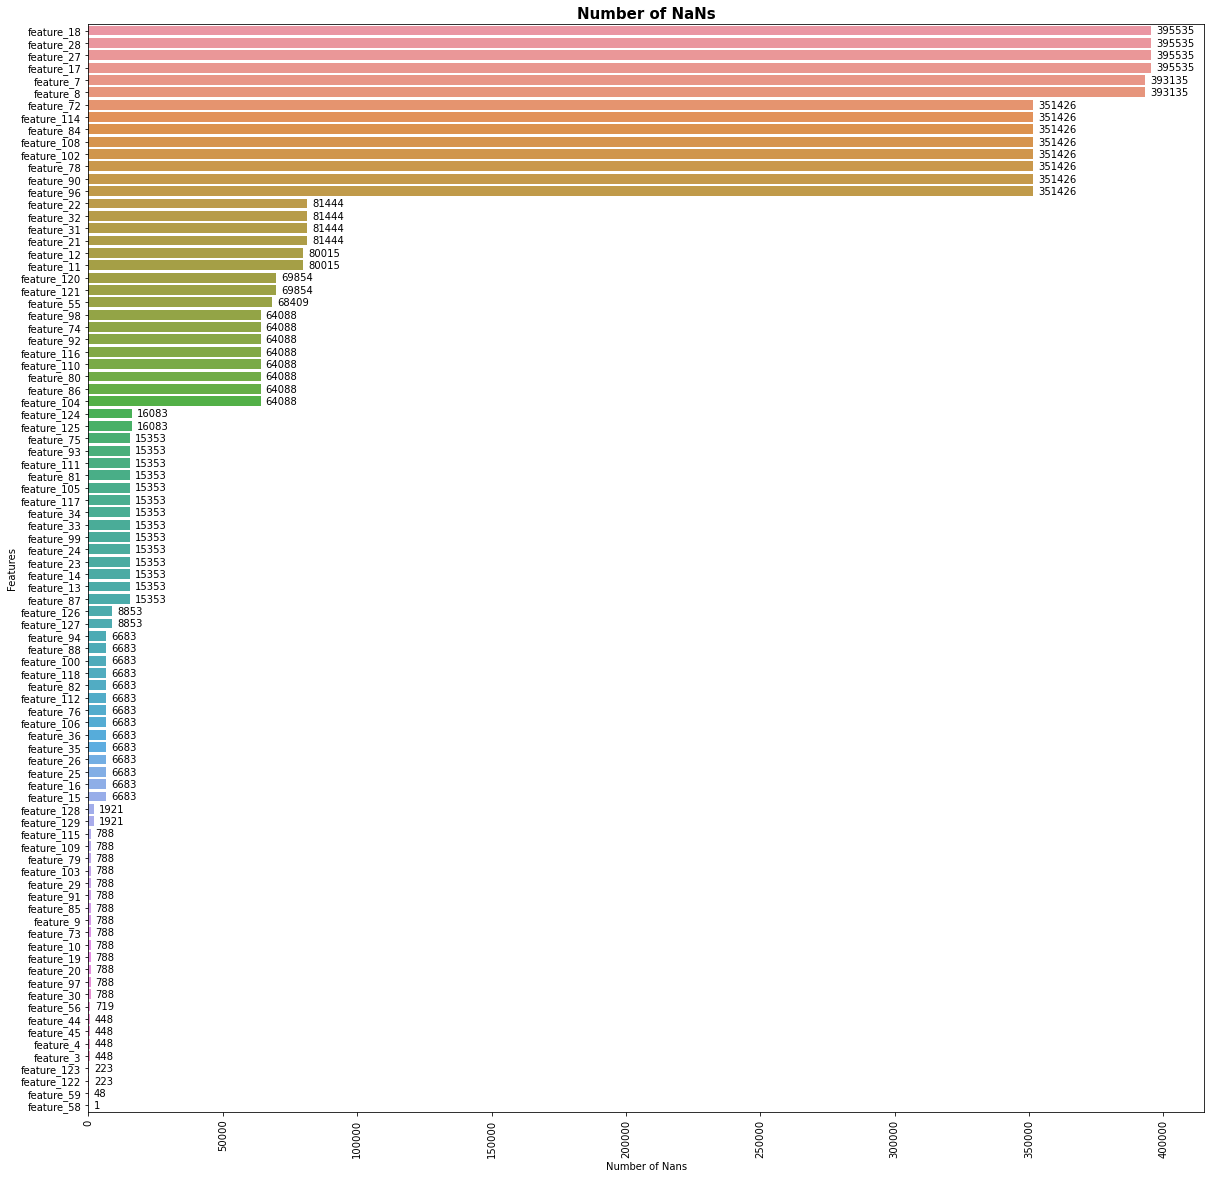

In [13]:
null_df = null_df.sort_values(by="number_of_nan",ascending=False)
plt.figure(figsize=(20,20))
plots=sns.barplot(x=null_df.number_of_nan,y=null_df.index,
             data=null_df)
for p in plots.patches:
    plots.annotate("%d" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
            xytext=(5, 0), textcoords='offset points', ha="left", va="center")
plt.xticks(rotation='vertical')
plt.title("Number of NaNs", fontweight='bold', fontsize=15)
plt.xlabel("Number of Nans")
plt.ylabel("Features")
plt.show()

In [14]:
#imputing null values with mean in the dataset
data.fillna(data.mean(),inplace=True)

### Analyzing weight column

In [15]:
#Calculating perecentage of records where weight = 0
zero_weights_percentage = (data['weight'] == 0).sum() / len(data['weight']) * 100
print(f'Perecentage of records where weight is zero is upto {round(zero_weights_percentage)}%')

Perecentage of records where weight is zero is upto 17%


### Visual representation of weight column

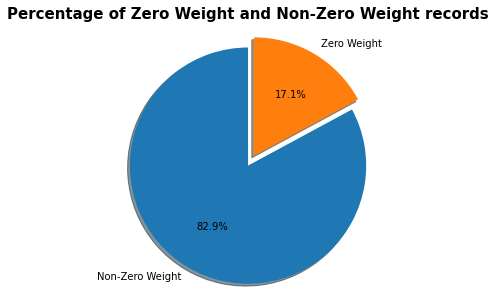

In [16]:
labels = 'Non-Zero Weight', 'Zero Weight'
zero_weights = (data['weight'] == 0).sum() 
non_zero_weights = (len(data['weight'])) - ((data['weight'] == 0).sum())

sizes = [non_zero_weights,zero_weights]
explode = (0, 0.1)  

plt.figure(figsize=(5,5))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',shadow=True, startangle=90)
plt.axis('equal')  
plt.title("Percentage of Zero Weight and Non-Zero Weight records", fontweight='bold', fontsize=15)
plt.show()

In [17]:
#dropping records where weight = 0
data = data[data['weight'] != 0]

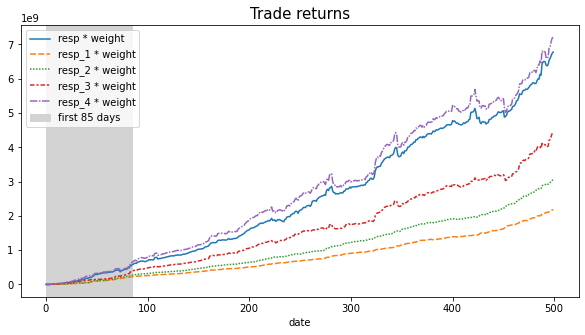

In [18]:
#Each trade has an associated weight and resp, which together represents a return on the trade
#calculating trade for each resp 
df = pd.DataFrame(data.groupby('date')[['resp_1', 'resp_2', 'resp_3', 'resp_4', 'resp','weight']].sum().cumsum())
df['resp * weight'] = df['resp'] * df['weight']
df['resp_1 * weight'] = df['resp_1'] * df['weight']
df['resp_2 * weight'] = df['resp_2'] * df['weight']
df['resp_3 * weight'] = df['resp_3'] * df['weight']
df['resp_4 * weight'] = df['resp_4'] * df['weight']

new_df =df[['resp * weight','resp_1 * weight','resp_2 * weight','resp_3 * weight','resp_4 * weight']]

plt.figure(figsize=(10,5))
sns.lineplot(data=new_df)
plt.title ("Trade returns", fontsize=15)
plt.axvspan(0,85,color = 'lightgray',label='first 85 days')
plt.legend(loc="upper left")

In [19]:
#dropping records before day 85
data = data.query('date > 85').reset_index(drop = True) 

In [20]:
data

,date,weight,resp_1,resp_2,resp_3,resp_4,resp,feature_0,feature_1,feature_2,...,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,ts_id
0,86,0.859516,-0.003656,-0.005449,-0.017403,-0.028896,-0.021435,1,3.151305,5.467693,...,0.268776,2.433699,4.282284,1.621115,4.331030,2.553220,3.799011,2.642943,3.998054,527894
1,86,0.590949,0.000347,-0.000376,-0.004051,-0.007995,-0.004743,-1,-0.365888,0.824004,...,0.268776,-0.702873,4.038753,-0.789767,4.133183,-1.207878,3.402796,-0.928290,3.511141,527896
2,86,0.172997,0.000168,0.000333,-0.002375,-0.003064,0.001527,1,1.514607,0.596214,...,0.268776,2.304354,1.530169,3.596848,4.613493,4.516110,3.341374,2.635798,1.535235,527897
3,86,1.507813,0.001534,0.000481,-0.000082,-0.002271,-0.001663,-1,-1.008999,0.242132,...,0.268776,-1.700655,-0.376747,-0.876730,1.645537,-1.318172,1.369452,-1.352577,0.733124,527900
4,86,5.554003,0.003948,0.005943,0.015943,0.025001,0.017121,-1,-0.391784,0.152261,...,0.268776,-1.690686,1.656818,-1.213169,2.949877,-2.033542,2.248799,-1.838696,1.905638,527901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571410,499,56.694795,0.001607,0.001607,-0.001245,-0.012068,-0.010023,-1,1.538675,2.530447,...,-2.084489,-0.984942,1.129901,-1.632432,-2.169964,-2.371293,-0.889212,-1.554352,0.215984,2390444
1571411,499,1.650055,0.004523,0.004523,0.003172,-0.013886,-0.013637,1,0.270380,-1.231874,...,-1.982950,1.724863,-0.984278,1.413825,-1.598825,2.087731,-1.126050,1.590538,-1.250209,2390446
1571412,499,0.895142,0.000486,0.000486,-0.004090,-0.008105,-0.005441,-1,-0.134380,0.160580,...,-2.103206,-0.765664,-2.148415,-0.599358,-3.155134,-0.957971,-2.285314,-0.894580,-2.064227,2390478
1571413,499,2.967272,0.000298,0.000298,-0.005393,-0.012472,-0.006681,-1,-0.779554,-0.597258,...,-3.453253,1.173186,-1.215499,0.170404,-3.433334,0.496345,-2.224752,1.207851,-1.264984,2390481


In [21]:
#Creating a dataframe with number of null values each column has, in features dataset
null_values_f=features_df.isnull().sum()
null_df_f = pd.DataFrame(null_values_f,columns=['number_of_nan'])
null_df_f

,number_of_nan
tag_0,0
tag_1,0
tag_2,0
tag_3,0
tag_4,0
tag_5,0
tag_6,0
tag_7,0
tag_8,0
tag_9,0


In [22]:
#converting true/false to 1/0 
# 1 represents true
# 0 represents false
features_df=(features_df * 1)
features_df

,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,...,tag_19,tag_20,tag_21,tag_22,tag_23,tag_24,tag_25,tag_26,tag_27,tag_28
feature,,,,,,,,,,,,,,,,,,,,,
feature_0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
feature_1,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
feature_2,0,0,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
feature_3,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
feature_4,0,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
feature_125,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
feature_126,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
feature_127,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [23]:
#counting number of tags each feature has
tags_count = features_df.sum(axis = 1)
tags_count_df= pd.DataFrame(tags_count,columns=['number_of_tags'])
tags_count_df

,number_of_tags
feature,
feature_0,0
feature_1,2
feature_2,3
feature_3,2
feature_4,3
...,...
feature_125,3
feature_126,2
feature_127,3


### Visualizing tag count for each feature

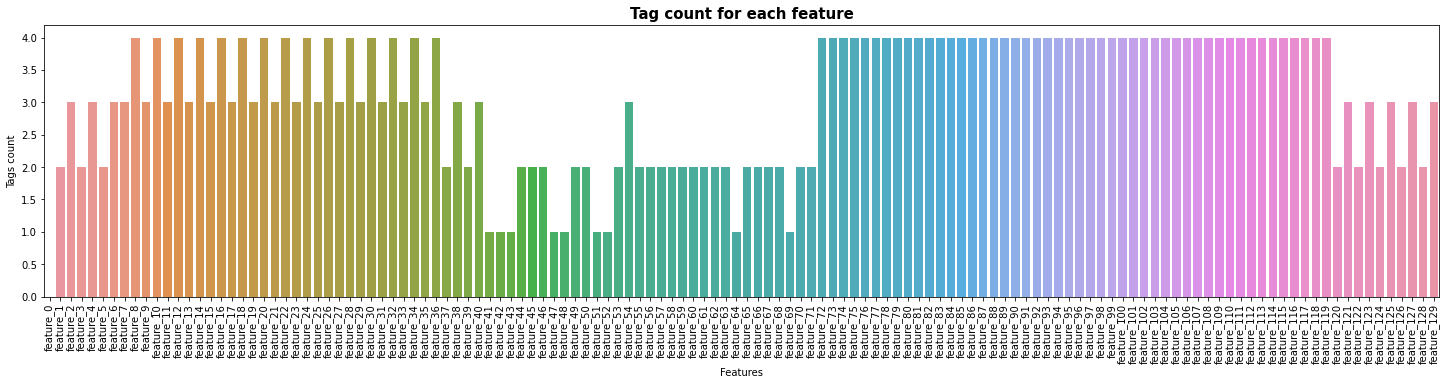

In [24]:
plt.figure(figsize=(25,5))
sns.barplot(x=tags_count_df.index,y=tags_count_df.number_of_tags,
             data=tags_count_df)
plt.xticks(rotation='vertical')
plt.title("Tag count for each feature", fontweight='bold', fontsize=15)
plt.xlabel("Features")
plt.ylabel("Tags count")
plt.show()

In [25]:
# calculating number of features each tag has
tags_feature_count= features_df.sum(axis = 0)
tags_feature_count_df= pd.DataFrame(tags_feature_count,columns=['number_of_features'])
tags_feature_count_df

,number_of_features
tag_0,17
tag_1,17
tag_2,17
tag_3,17
tag_4,17
tag_5,8
tag_6,40
tag_7,2
tag_8,2
tag_9,21


### Visualizing feature count for each tag

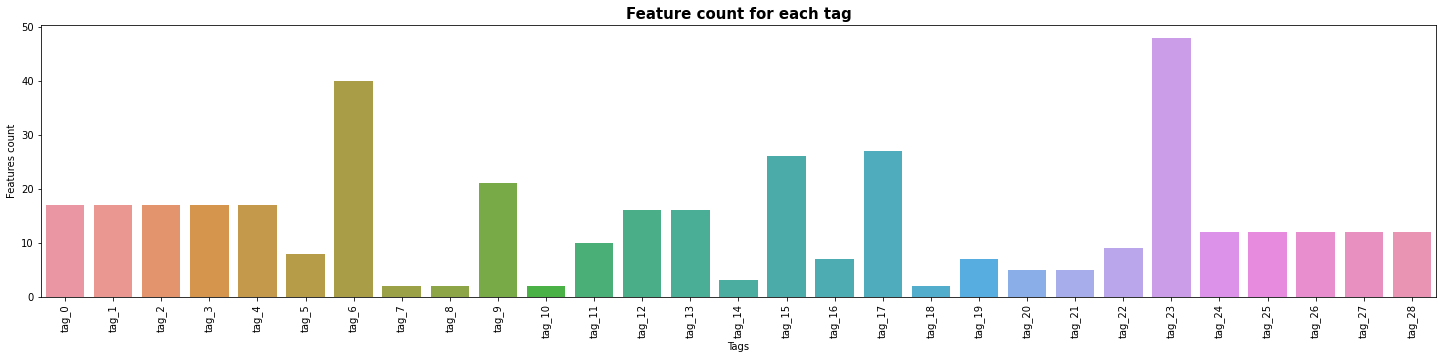

In [26]:
plt.figure(figsize=(25,5))
sns.barplot(x=tags_feature_count_df.index,y=tags_feature_count_df.number_of_features,
             data=tags_feature_count_df)
plt.xticks(rotation='vertical')
plt.title("Feature count for each tag", fontweight='bold', fontsize=15)
plt.xlabel("Tags")
plt.ylabel("Features count")
plt.show()

### Heat Map demostrating correlation between features

<AxesSubplot:>

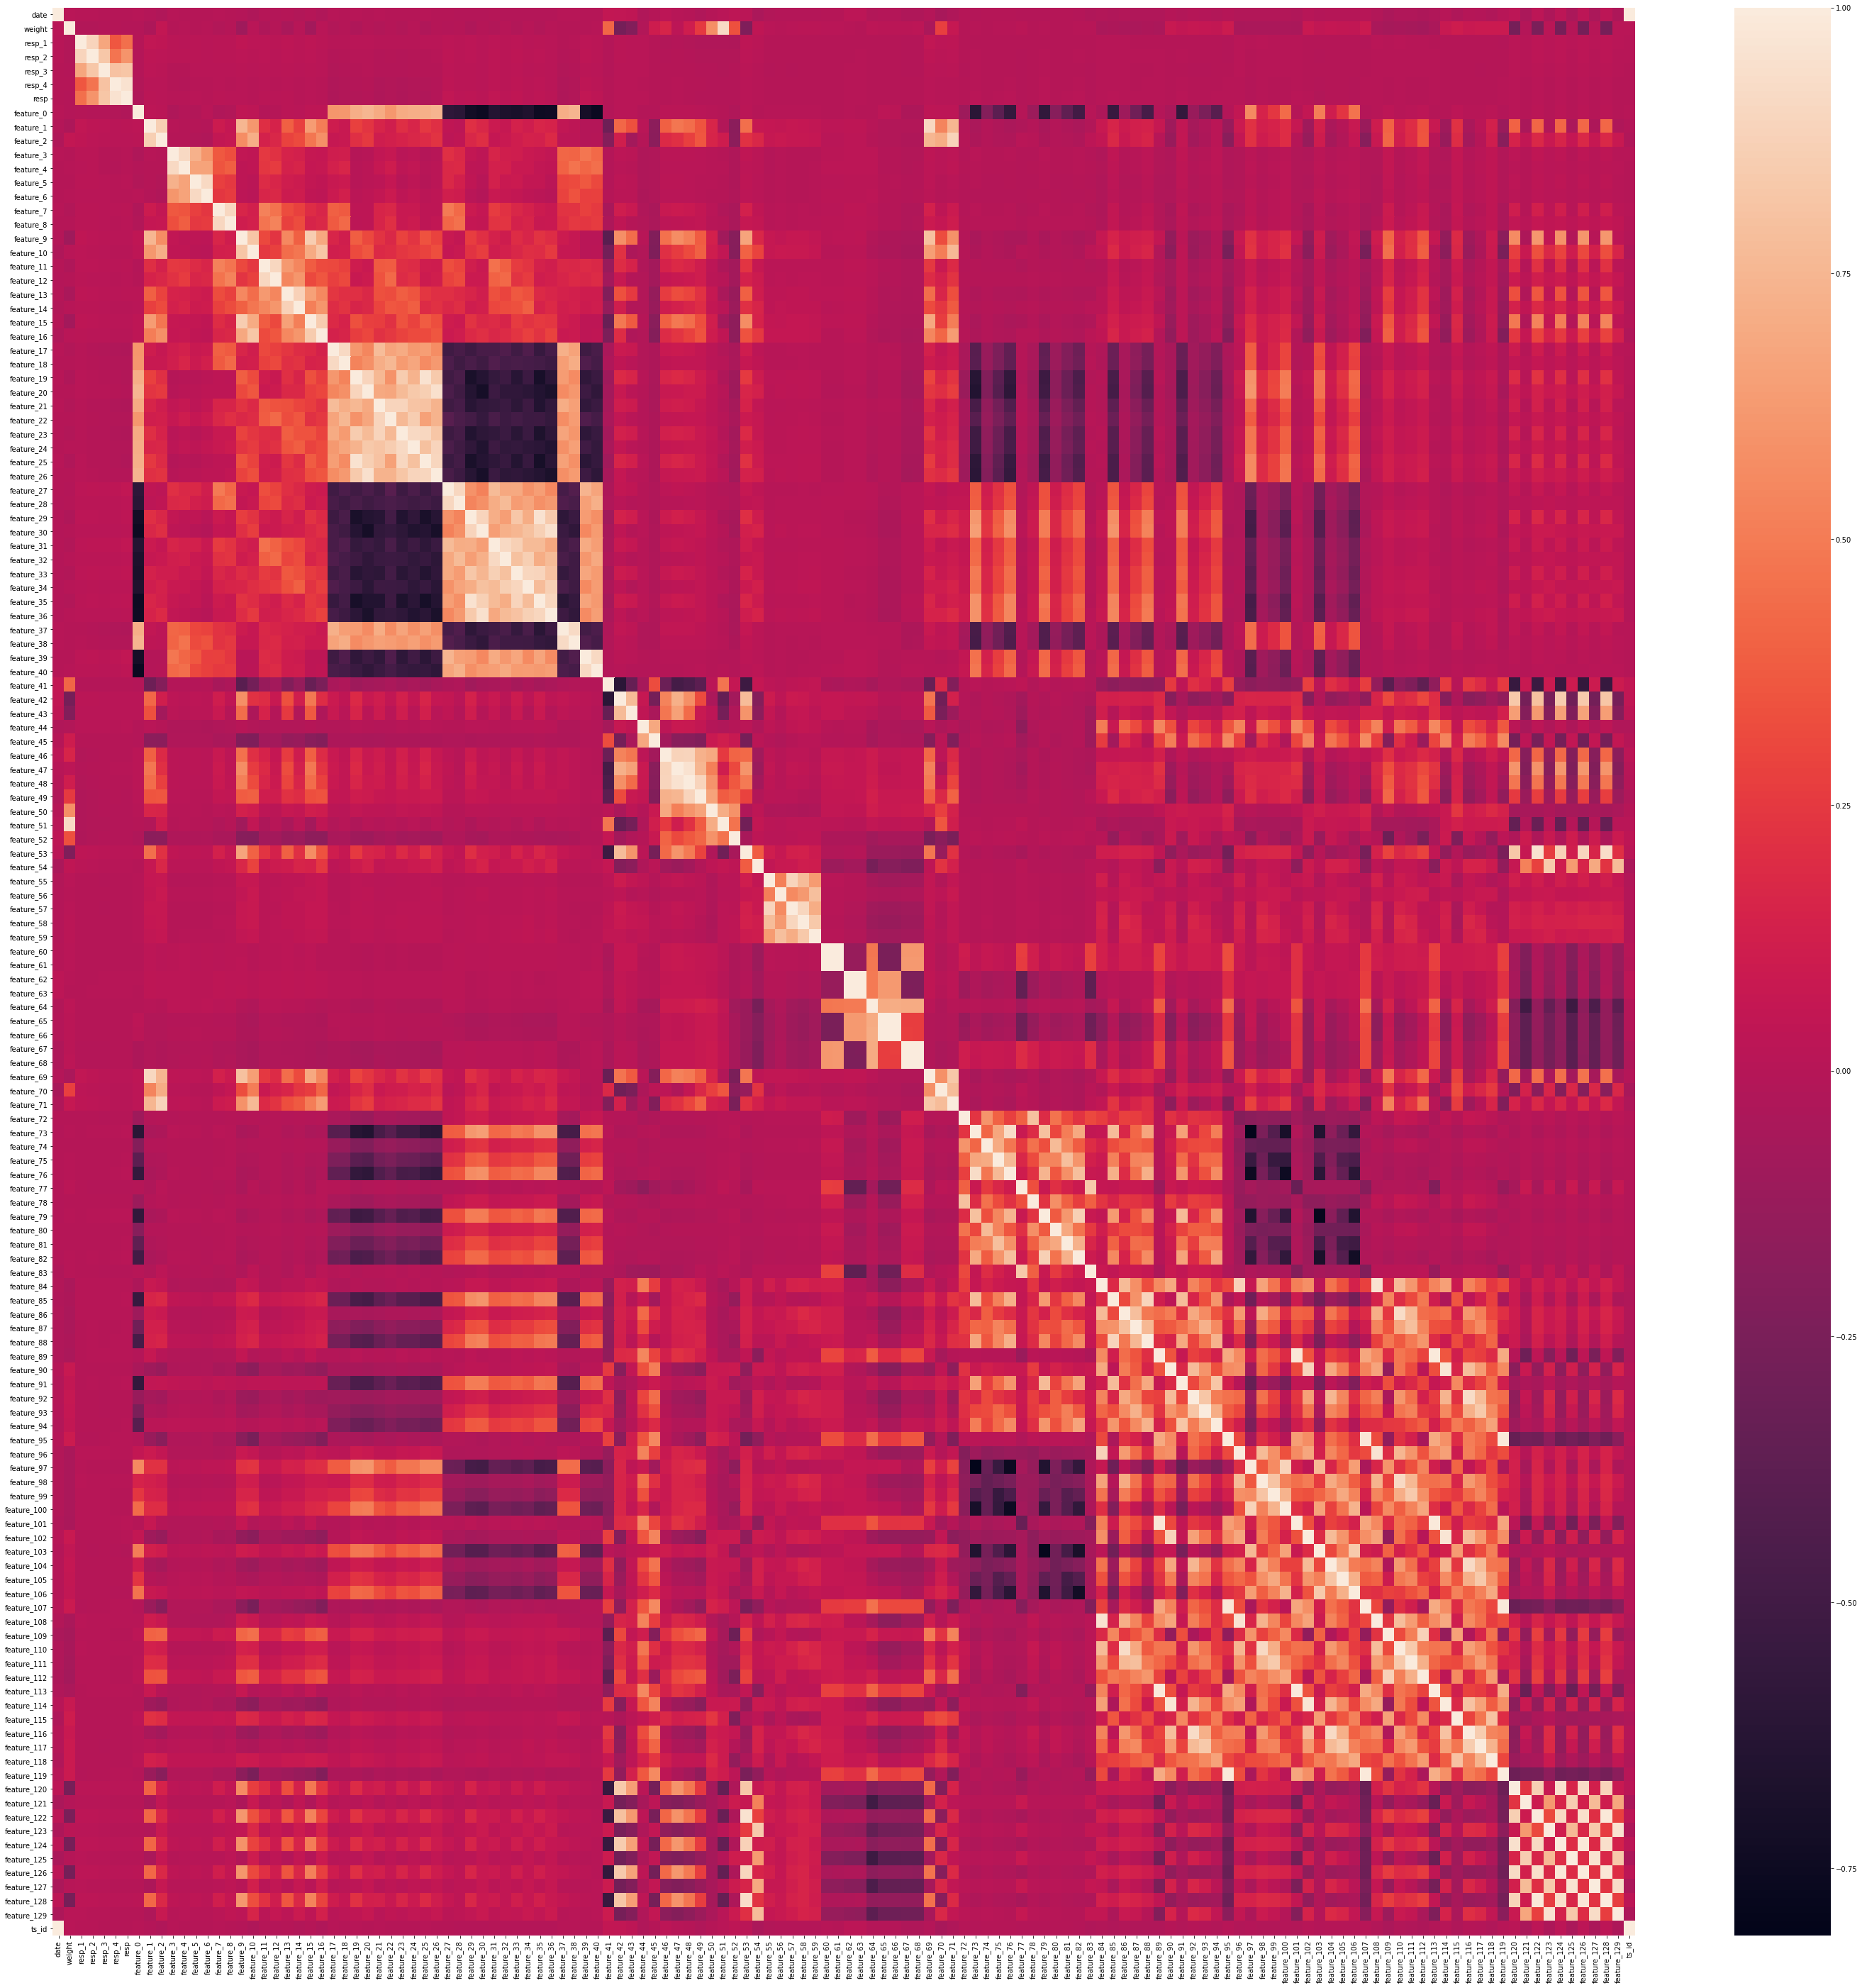

In [27]:
%matplotlib inline

#Calculating correlation for variables present in the dataset
cor = data.corr()

plt.figure(figsize=(50,50))
sns.heatmap(cor,annot = False)


### Box plot of features to check outliers

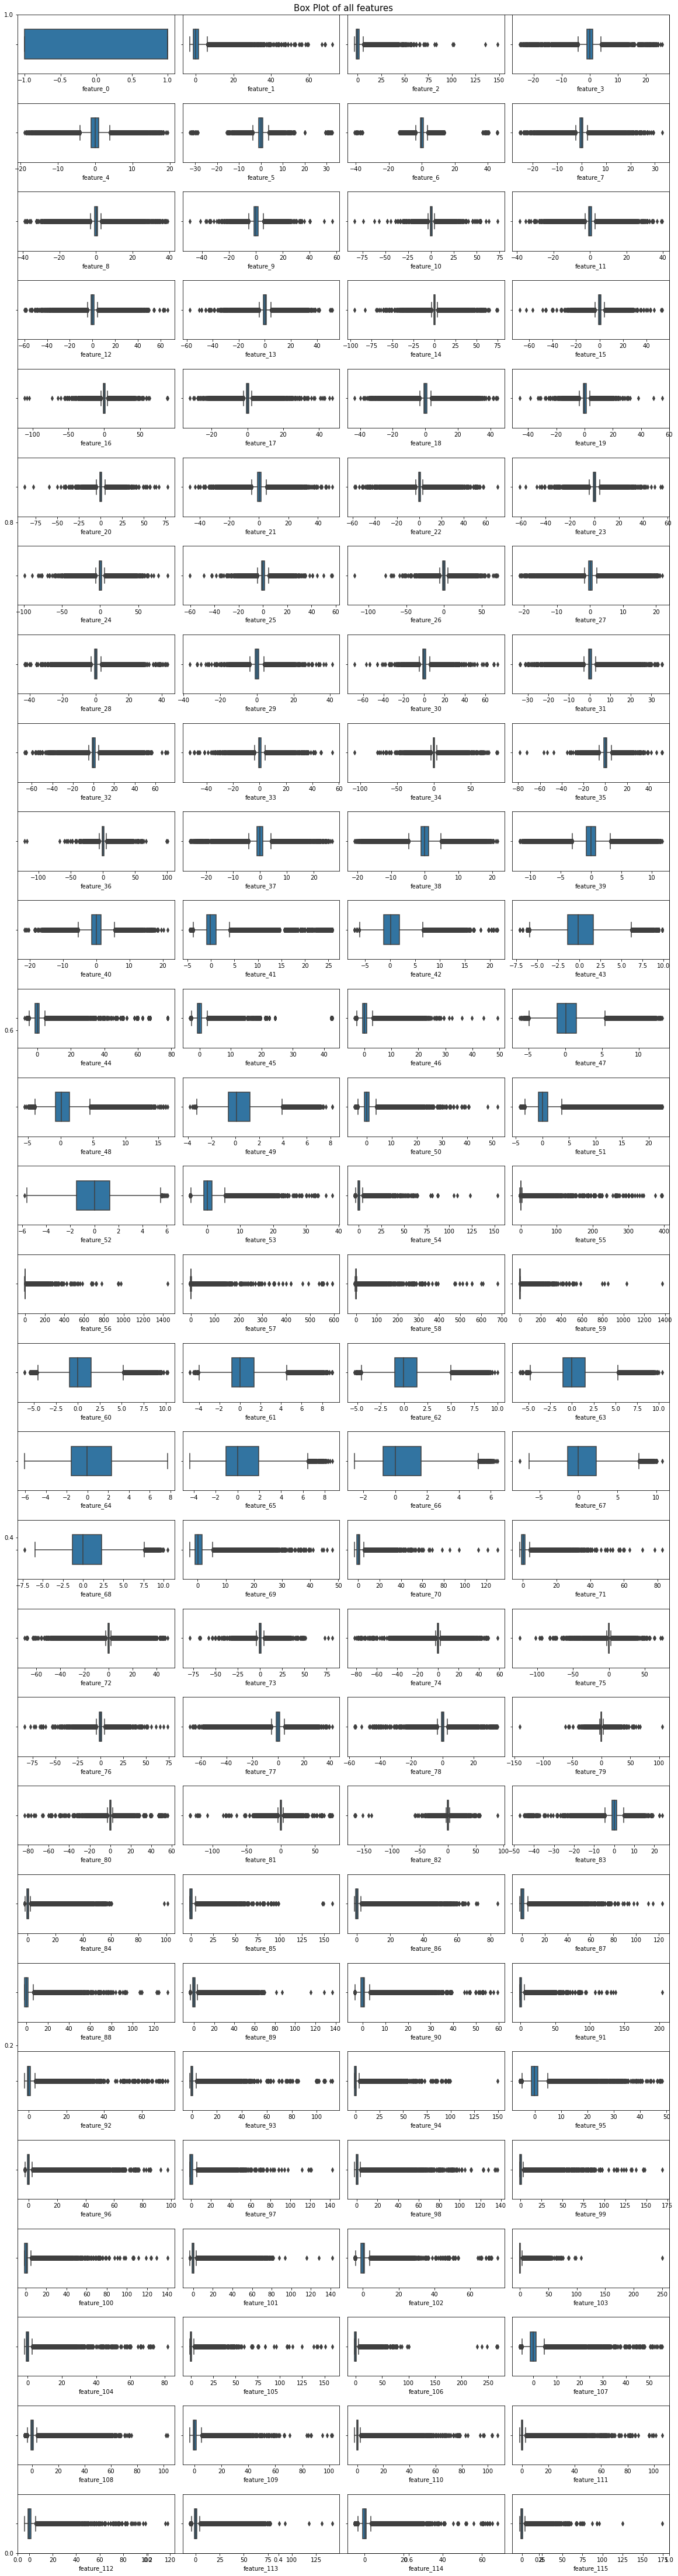

In [28]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20,80))
#extracting features names
featstr= [c for c in data.columns if "feature" in c]
plt.title('Box Plot of all features',fontsize=15)
#creating a grid
grid =  gridspec.GridSpec(29,4,figure=fig,hspace=.5,wspace=.05)
counter = 0
for i in range(29):
    for j in range(4):
        sub_plot = fig.add_subplot(grid[i, j]);
        sns.boxplot(x= data[featstr[counter]], ax= sub_plot,width=.5);
        counter += 1
plt.show()

# Approch 1

## Creating target variable - if resp >0 then action = 1, else action =0

In [29]:
data['action'] = ((data['resp'].values) > 0).astype(int)

In [30]:
data['action'].value_counts()

1    789325
0    782090
Name: action, dtype: int64

In [31]:
data

,date,weight,resp_1,resp_2,resp_3,resp_4,resp,feature_0,feature_1,feature_2,...,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,ts_id,action
0,86,0.859516,-0.003656,-0.005449,-0.017403,-0.028896,-0.021435,1,3.151305,5.467693,...,2.433699,4.282284,1.621115,4.331030,2.553220,3.799011,2.642943,3.998054,527894,0
1,86,0.590949,0.000347,-0.000376,-0.004051,-0.007995,-0.004743,-1,-0.365888,0.824004,...,-0.702873,4.038753,-0.789767,4.133183,-1.207878,3.402796,-0.928290,3.511141,527896,0
2,86,0.172997,0.000168,0.000333,-0.002375,-0.003064,0.001527,1,1.514607,0.596214,...,2.304354,1.530169,3.596848,4.613493,4.516110,3.341374,2.635798,1.535235,527897,1
3,86,1.507813,0.001534,0.000481,-0.000082,-0.002271,-0.001663,-1,-1.008999,0.242132,...,-1.700655,-0.376747,-0.876730,1.645537,-1.318172,1.369452,-1.352577,0.733124,527900,0
4,86,5.554003,0.003948,0.005943,0.015943,0.025001,0.017121,-1,-0.391784,0.152261,...,-1.690686,1.656818,-1.213169,2.949877,-2.033542,2.248799,-1.838696,1.905638,527901,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571410,499,56.694795,0.001607,0.001607,-0.001245,-0.012068,-0.010023,-1,1.538675,2.530447,...,-0.984942,1.129901,-1.632432,-2.169964,-2.371293,-0.889212,-1.554352,0.215984,2390444,0
1571411,499,1.650055,0.004523,0.004523,0.003172,-0.013886,-0.013637,1,0.270380,-1.231874,...,1.724863,-0.984278,1.413825,-1.598825,2.087731,-1.126050,1.590538,-1.250209,2390446,0
1571412,499,0.895142,0.000486,0.000486,-0.004090,-0.008105,-0.005441,-1,-0.134380,0.160580,...,-0.765664,-2.148415,-0.599358,-3.155134,-0.957971,-2.285314,-0.894580,-2.064227,2390478,0
1571413,499,2.967272,0.000298,0.000298,-0.005393,-0.012472,-0.006681,-1,-0.779554,-0.597258,...,1.173186,-1.215499,0.170404,-3.433334,0.496345,-2.224752,1.207851,-1.264984,2390481,0


### 1.1 Feature selection using Random Forest tree

In [32]:
from sklearn.ensemble import RandomForestClassifier
target='action'
cols_drop = list(np.setdiff1d(data.columns,test.columns))+['ts_id','date']

clf = RandomForestClassifier()

In [33]:
clf.fit(data.drop(cols_drop,axis=1),data['action'])

RandomForestClassifier()

In [34]:
top=20
top_features = np.argsort(clf.feature_importances_)[::-1][:top]
feature_names = data.drop(cols_drop,axis=1).iloc[:,top_features].columns

### Graphical representation of important features

C:\Users\psath\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

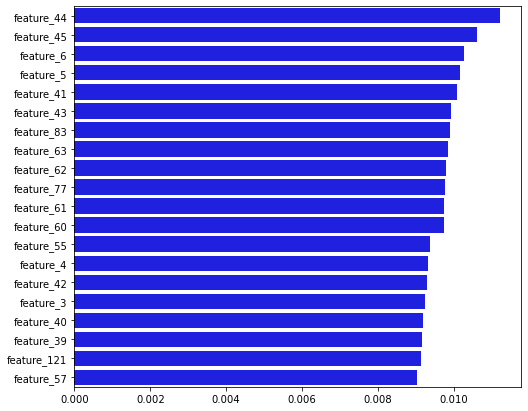

In [35]:
plt.figure(figsize=(8,7))
sns.barplot(clf.feature_importances_[top_features],feature_names,color='blue')

In [36]:
feature_names

Index(['feature_44', 'feature_45', 'feature_6', 'feature_5', 'feature_41',
       'feature_43', 'feature_83', 'feature_63', 'feature_62', 'feature_77',
       'feature_61', 'feature_60', 'feature_55', 'feature_4', 'feature_42',
       'feature_3', 'feature_40', 'feature_39', 'feature_121', 'feature_57'],
      dtype='object')

### 1.2 Extracting important features and Splitting the cleaned data(train.csv)

In [82]:
X= data[feature_names]

y = data['action']

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42, shuffle=True)

### 1.3 Model 1: Multiple layer perceptron

In [85]:
from sklearn.neural_network import MLPClassifier
batch_size = 4096
hidden_units = [150, 150, 150]
learning_rate = 3e-3

clf_mlp= MLPClassifier(hidden_layer_sizes=hidden_units, max_iter=100,activation = 'logistic',solver="lbfgs",batch_size=batch_size,
                           learning_rate_init=learning_rate)

clf_mlp.fit(X_train, y_train)

MLPClassifier(activation='logistic', batch_size=4096,
              hidden_layer_sizes=[150, 150, 150], learning_rate_init=0.003,
              max_iter=100, solver='lbfgs')

In [86]:
pred_clf_mlp = clf_mlp.predict(X_test)

In [87]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,pred_clf_mlp))
print(classification_report(y_test,pred_clf_mlp))

[[ 10019 615424]
 [ 10206 621483]]
              precision    recall  f1-score   support

           0       0.50      0.02      0.03    625443
           1       0.50      0.98      0.67    631689

    accuracy                           0.50   1257132
   macro avg       0.50      0.50      0.35   1257132
weighted avg       0.50      0.50      0.35   1257132



In [88]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, pred_clf_mlp))

Accuracy: 0.5023354747154635


### 1.4 Model 2 : Decision Tree

In [89]:
from sklearn import tree
clf_dt = tree.DecisionTreeClassifier()

In [90]:
clf_dt = clf_dt.fit(X_train, y_train)

In [91]:
pred_clf_dt=clf_dt.predict(X_test)

In [92]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,pred_clf_dt))
print(classification_report(y_test,pred_clf_dt))

[[374822 250621]
 [252364 379325]]
              precision    recall  f1-score   support

           0       0.60      0.60      0.60    625443
           1       0.60      0.60      0.60    631689

    accuracy                           0.60   1257132
   macro avg       0.60      0.60      0.60   1257132
weighted avg       0.60      0.60      0.60   1257132



In [93]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, pred_clf_dt))

Accuracy: 0.5998948400008909


### 1.5 Model 3 : Random Forest Tree

In [94]:
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier(n_estimators=100, max_leaf_nodes=32, n_jobs=-1, verbose=2)
clf_rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100building tree 8 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100building tree 27 of 100

building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.0s


building tree 33 of 100
building tree 34 of 100
building tree 35 of 100building tree 36 of 100

building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   21.6s finished


RandomForestClassifier(max_leaf_nodes=32, n_jobs=-1, verbose=2)

In [95]:
pred_clf_rf = clf_rf.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    2.2s finished


In [96]:
print(confusion_matrix(y_test,pred_clf_rf))
print(classification_report(y_test,pred_clf_rf))

[[334236 291207]
 [310638 321051]]
              precision    recall  f1-score   support

           0       0.52      0.53      0.53    625443
           1       0.52      0.51      0.52    631689

    accuracy                           0.52   1257132
   macro avg       0.52      0.52      0.52   1257132
weighted avg       0.52      0.52      0.52   1257132



In [97]:
print("Accuracy:",metrics.accuracy_score(y_test,pred_clf_rf))

Accuracy: 0.5212555244795296


# Approch 2

## Creating Target Variable - if (resp * weight) & (resp_1 * weight) & (resp_2 * weight) & (resp_3 * weight) & (resp_4 * weight) > 0 
## then action = 1 else action = 0

In [106]:
data['resp * weight'] = data['resp'] * data['weight']
data['resp_1 * weight'] = data['resp_1'] * data['weight']
data['resp_2 * weight'] = data['resp_2'] * data['weight']
data['resp_3 * weight'] = data['resp_3'] * data['weight']
data['resp_4 * weight'] = data['resp_4'] * data['weight']

data['action'] = (((data['resp * weight'].values) > 0) & ((data['resp_1 * weight'].values) > 0) & ((data['resp_2 * weight'].values) > 0) &
((data['resp_3 * weight'].values) > 0) & ((data['resp_4 * weight'].values) > 0)).astype(int)

In [107]:
data['action'].value_counts()

0    1155384
1     416031
Name: action, dtype: int64

In [108]:
data

,date,weight,resp_1,resp_2,resp_3,resp_4,resp,feature_0,feature_1,feature_2,...,feature_127,feature_128,feature_129,ts_id,action,resp * weight,resp_1 * weight,resp_2 * weight,resp_3 * weight,resp_4 * weight
0,86,0.859516,-0.003656,-0.005449,-0.017403,-0.028896,-0.021435,1,3.151305,5.467693,...,3.799011,2.642943,3.998054,527894,0,-0.018424,-0.003143,-0.004684,-0.014958,-0.024836
1,86,0.590949,0.000347,-0.000376,-0.004051,-0.007995,-0.004743,-1,-0.365888,0.824004,...,3.402796,-0.928290,3.511141,527896,0,-0.002803,0.000205,-0.000222,-0.002394,-0.004725
2,86,0.172997,0.000168,0.000333,-0.002375,-0.003064,0.001527,1,1.514607,0.596214,...,3.341374,2.635798,1.535235,527897,0,0.000264,0.000029,0.000058,-0.000411,-0.000530
3,86,1.507813,0.001534,0.000481,-0.000082,-0.002271,-0.001663,-1,-1.008999,0.242132,...,1.369452,-1.352577,0.733124,527900,0,-0.002508,0.002313,0.000725,-0.000123,-0.003425
4,86,5.554003,0.003948,0.005943,0.015943,0.025001,0.017121,-1,-0.391784,0.152261,...,2.248799,-1.838696,1.905638,527901,1,0.095091,0.021930,0.033008,0.088547,0.138856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571410,499,56.694795,0.001607,0.001607,-0.001245,-0.012068,-0.010023,-1,1.538675,2.530447,...,-0.889212,-1.554352,0.215984,2390444,0,-0.568231,0.091094,0.091094,-0.070586,-0.684212
1571411,499,1.650055,0.004523,0.004523,0.003172,-0.013886,-0.013637,1,0.270380,-1.231874,...,-1.126050,1.590538,-1.250209,2390446,0,-0.022502,0.007464,0.007464,0.005234,-0.022913
1571412,499,0.895142,0.000486,0.000486,-0.004090,-0.008105,-0.005441,-1,-0.134380,0.160580,...,-2.285314,-0.894580,-2.064227,2390478,0,-0.004870,0.000435,0.000435,-0.003661,-0.007255
1571413,499,2.967272,0.000298,0.000298,-0.005393,-0.012472,-0.006681,-1,-0.779554,-0.597258,...,-2.224752,1.207851,-1.264984,2390481,0,-0.019825,0.000883,0.000883,-0.016001,-0.037007


### 2.1 Feature selection using Random Forest tree

In [109]:
from sklearn.ensemble import RandomForestClassifier
target='action'
cols_drop = list(np.setdiff1d(data.columns,test.columns))+['ts_id','date']

clf = RandomForestClassifier()

In [110]:
clf.fit(data.drop(cols_drop,axis=1),data['action'])

RandomForestClassifier()

In [111]:
top=20
top_features = np.argsort(clf.feature_importances_)[::-1][:top]
feature_names = data.drop(cols_drop,axis=1).iloc[:,top_features].columns

### Graphical representation of important features

C:\Users\psath\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

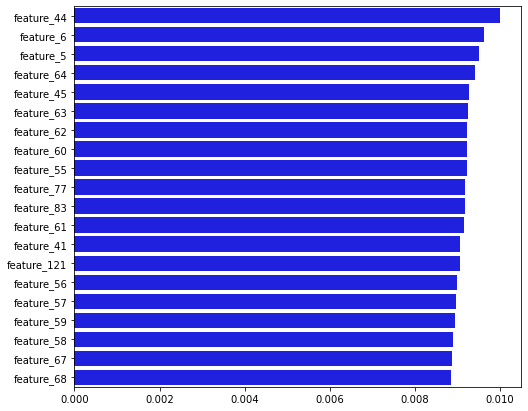

In [112]:
plt.figure(figsize=(8,7))
sns.barplot(clf.feature_importances_[top_features],feature_names,color='blue')

In [113]:
feature_names

Index(['feature_44', 'feature_6', 'feature_5', 'feature_64', 'feature_45',
       'feature_63', 'feature_62', 'feature_60', 'feature_55', 'feature_77',
       'feature_83', 'feature_61', 'feature_41', 'feature_121', 'feature_56',
       'feature_57', 'feature_59', 'feature_58', 'feature_67', 'feature_68'],
      dtype='object')

### 2.2 Extracting important features and Splitting the cleaned data(train.csv)

In [114]:
X= data[feature_names]

y = data['action']

In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42, shuffle=True)

### 2.3 Model 1: Multiple layer perceptron

In [116]:
from sklearn.neural_network import MLPClassifier
batch_size = 4096
hidden_units = [150, 150, 150]
learning_rate = 3e-3

clf_mlp= MLPClassifier(hidden_layer_sizes=hidden_units, max_iter=100,activation = 'logistic',solver="lbfgs",batch_size=batch_size,
                           learning_rate_init=learning_rate)

clf_mlp.fit(X_train, y_train)

MLPClassifier(activation='logistic', batch_size=4096,
              hidden_layer_sizes=[150, 150, 150], learning_rate_init=0.003,
              max_iter=100, solver='lbfgs')

In [117]:
pred_clf_mlp = clf_mlp.predict(X_test)

In [118]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,pred_clf_mlp))
print(classification_report(y_test,pred_clf_mlp))

[[924363      0]
 [332769      0]]


C:\Users\psath\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.74      1.00      0.85    924363
           1       0.00      0.00      0.00    332769

    accuracy                           0.74   1257132
   macro avg       0.37      0.50      0.42   1257132
weighted avg       0.54      0.74      0.62   1257132



In [119]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, pred_clf_mlp))

Accuracy: 0.735295100275866


### 2.4 Model 2 : Decision Tree

In [120]:
from sklearn import tree
clf_dt = tree.DecisionTreeClassifier()

In [121]:
clf_dt = clf_dt.fit(X_train, y_train)

In [122]:
pred_clf_dt=clf_dt.predict(X_test)

In [123]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,pred_clf_dt))
print(classification_report(y_test,pred_clf_dt))

[[677816 246547]
 [225887 106882]]
              precision    recall  f1-score   support

           0       0.75      0.73      0.74    924363
           1       0.30      0.32      0.31    332769

    accuracy                           0.62   1257132
   macro avg       0.53      0.53      0.53   1257132
weighted avg       0.63      0.62      0.63   1257132



In [124]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, pred_clf_dt))

Accuracy: 0.6241969817012056


### 2.5 Model 3 : Random Forest Tree

In [141]:
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier(n_estimators=100, max_leaf_nodes=32, n_jobs=-1, verbose=2)
clf_rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.1s


building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   18.7s finished


RandomForestClassifier(max_leaf_nodes=32, n_jobs=-1, verbose=2)

In [142]:
pred_clf_rf = clf_rf.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.9s finished


In [143]:
print(confusion_matrix(y_test,pred_clf_rf))
print(classification_report(y_test,pred_clf_rf))

[[924363      0]
 [332769      0]]


C:\Users\psath\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.74      1.00      0.85    924363
           1       0.00      0.00      0.00    332769

    accuracy                           0.74   1257132
   macro avg       0.37      0.50      0.42   1257132
weighted avg       0.54      0.74      0.62   1257132



In [144]:
print("Accuracy:",metrics.accuracy_score(y_test,pred_clf_rf))

Accuracy: 0.735295100275866
